# AI-POWERED-BANKING-FRAUD-DECTECTION ANALYSIS

# 1. Overview

NexaBank is a modern, technology-first financial institution committed to delivering secure, seamless, and intelligent banking experiences to its customers. Operating across digital channels - mobile, web, and ATM. NexaBank serves a diverse global customer base processing millions of transactions daily. As the bank scales rapidly, safeguarding customers from financial fraud has become one of its highest strategic priorities.

## 1.1 Business Understanding

The global banking industry loses hundreds of billions of dollars annually to fraudulent transactions. As digital payments grow, driven by mobile banking, e-commerce, and real-time transfers, so too does the sophistication of fraud. NexaBank's existing rule-based detection systems are no longer sufficient. They are slow to adapt, generate excessive false alerts, and miss novel fraud patterns that fall outside predefined rules, putting customers and the bank at growing risk.

## 1.2 Business Problem

NexaBank faces a dual challenge: detecting fraudulent transactions accurately and in real time, while ensuring that legitimate customers experience no unnecessary friction. Every undetected fraud transaction results in direct financial loss and erodes customer trust. Every legitimate transaction incorrectly blocked damages the customer relationship and risks churn. Manual review processes at NexaBank cannot operate at the speed and scale demanded by modern digital banking. M y Mission as a data scientist is to leverage AI and machine learning to build an intelligent, scalable fraud detection system for NexaBank that protects customers and the institution from fraudulent transactions — enabling real-time intervention, reducing financial losses, and preserving the trust that is at the heart of everything NexaBank does.

## 1.3 Objectives

1. To identify and prevent fraud in real time
2. To protect customers without disrupting their experience
3. To build model and deliver insights that drive smarter decsions

## 1.4 Research Questions

1. What transaction characteristics are most strongly associated with fraudulent activity in NexaBank's transaction data?
2. Which machine learning algorithm delivers the best performance for fraud detection on NexaBank's dataset?
3. Which features contribute most to the model's predictions, and what actionable insights do they reveal for NexaBank's fraud and risk teams?

## 1.5 Success Metrics

### Model performance
- ROC-AUC score ≥ 0.90 on the test set
- Recall (fraud class) ≥ 0.85 — catch at least 85% of all fraudulent transactions
- Precision ≥ 0.75 — limit false alerts to protect customer experience
- F1-score ≥ 0.80 — balance between precision and recall

### Business impact
- Reduction in false positives compared to NexaBank's current rule-based system
- Fraudulent transactions flagged before funds are transferred (real-time threshold < 100ms)

# 2. Data Understanding

This section explores the NexaBank transaction dataset to understand its structure, 
key variables, and underlying patterns that may distinguish fraudulent transactions 
from legitimate ones.

## 2.1  Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
from imblearn.over_sampling import SMOTE
import shap
import warnings
warnings.filterwarnings('ignore')

## 2.1 Loading the Dataset

In [2]:
bf = pd.read_csv(r"C:/Users/Admin/Documents/flatiron/flatiron/WINNIE_PROJECTS/Banking_Fraud_Dataset.csv")

## 2.1 Previewing Dataset

In [3]:
bf

,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Type,Transaction_Location,Transaction_Time,Device_Used,Account_Age,Credit_Score,Previous_Fraud,Is_Fraud
0,T1,C2539,8527.58,Deposit,"Hughesmouth, Mongolia",2025-01-20 03:17:34,Mobile,16,740,0,0
1,T2,C5318,9275.82,Deposit,"Huntville, Saint Pierre and Miquelon",2025-01-03 18:08:56,Web,5,848,0,1
2,T3,C8262,2202.49,Online Payment,"Patriciashire, Iceland",2025-01-24 05:54:01,ATM,2,616,1,1
3,T4,C3865,9352.32,Deposit,"Port Timothymouth, Palau",2025-01-19 01:15:30,ATM,9,437,1,0
4,T5,C7248,2081.75,Online Payment,"Lake Stevenfurt, Mauritius",2025-01-08 18:06:13,ATM,15,494,0,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,T9996,C2340,3678.03,Online Payment,"Port Matthew, Malawi",2025-01-14 05:47:08,Web,1,439,1,1
9996,T9997,C6185,6041.40,Transfer,"Lanceville, Swaziland",2025-01-08 04:40:34,POS Terminal,4,738,1,1
9997,T9998,C6114,4755.10,Online Payment,"North Scottmouth, Guinea-Bissau",2025-01-17 05:00:54,POS Terminal,18,649,1,1
9998,T9999,C4483,1649.96,Deposit,"North Miranda, Estonia",2025-01-23 09:44:47,POS Terminal,10,838,1,1


In [4]:
# Describe the DataFrame
bf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Transaction_ID        10000 non-null  object 
 1   Customer_ID           10000 non-null  object 
 2   Transaction_Amount    10000 non-null  float64
 3   Transaction_Type      10000 non-null  object 
 4   Transaction_Location  10000 non-null  object 
 5   Transaction_Time      10000 non-null  object 
 6   Device_Used           10000 non-null  object 
 7   Account_Age           10000 non-null  int64  
 8   Credit_Score          10000 non-null  int64  
 9   Previous_Fraud        10000 non-null  int64  
 10  Is_Fraud              10000 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 859.5+ KB


In [5]:
# Describe the  data
bf.describe()

,Transaction_Amount,Account_Age,Credit_Score,Previous_Fraud,Is_Fraud
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,4997.492361,10.646900,578.66280,0.501700,0.283800
std,2914.985459,5.760186,158.73193,0.500022,0.450863
min,10.890000,1.000000,300.00000,0.000000,0.000000
25%,2469.642500,6.000000,442.00000,0.000000,0.000000
50%,4985.325000,11.000000,581.00000,1.000000,0.000000
75%,7557.885000,16.000000,715.00000,1.000000,1.000000
max,9999.290000,20.000000,850.00000,1.000000,1.000000


## 2.3 Data preparation 

This section prepares the NexaBank dataset for modelling by converting data types, 
extracting meaningful features from date and location columns, encoding categorical 
variables, and dropping columns that are not useful for prediction.

### 2.3.1 Datetime connversion

In [8]:
# Convert Transaction_Time from object to datetime
bf['Transaction_Time'] = pd.to_datetime(bf['Transaction_Time'], dayfirst=True)

In [9]:
# Extract useful features from Transaction_Time
bf['Hour'] = bf['Transaction_Time'].dt.hour
bf['Day_of_Week'] = bf['Transaction_Time'].dt.dayofweek

### 2.3.2 Excating necessary columns and dropping irrelevant columns

In [11]:
# Extract Country from Transaction_Location
bf['Country'] = bf['Transaction_Location'].apply(lambda x: x.split(',')[-1].strip())

In [12]:
# 4. Drop columns not needed for modelling
bf.drop(columns=['Transaction_ID', 'Customer_ID', 'Transaction_Time', 'Transaction_Location'], inplace=True)

In [13]:
# Check missing values
print("Missing Values:")
print(bf.isnull().sum())

# Check duplicates
print(f"\nNumber of duplicate rows: {bf.duplicated().sum()}")

Missing Values:
Transaction_Amount    0
Transaction_Type      0
Device_Used           0
Account_Age           0
Credit_Score          0
Previous_Fraud        0
Is_Fraud              0
Hour                  0
Day_of_Week           0
Country               0
dtype: int64

Number of duplicate rows: 0


### 2.3.3 checking outliers

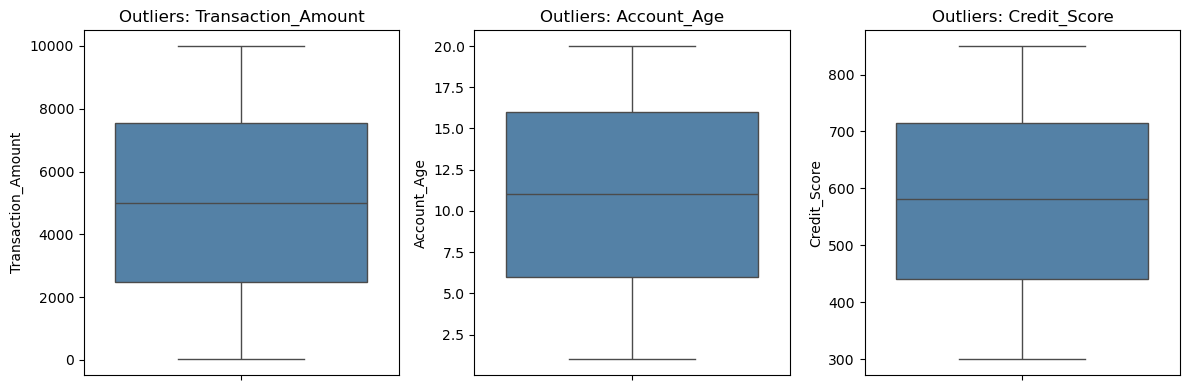

       Transaction_Amount   Account_Age  Credit_Score
count        10000.000000  10000.000000   10000.00000
mean          4997.492361     10.646900     578.66280
std           2914.985459      5.760186     158.73193
min             10.890000      1.000000     300.00000
25%           2469.642500      6.000000     442.00000
50%           4985.325000     11.000000     581.00000
75%           7557.885000     16.000000     715.00000
max           9999.290000     20.000000     850.00000


In [14]:
# Boxplots for numerical columns
numerical_cols = ['Transaction_Amount', 'Account_Age', 'Credit_Score']

plt.figure(figsize=(12, 4))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=bf[col], color='steelblue')
    plt.title(f'Outliers: {col}')
plt.tight_layout()
plt.show()

# Statistical summary to confirm
print(bf[numerical_cols].describe())

### Outlier Check

The boxplots reveal no extreme outliers across the three numerical features:

- **Transaction_Amount** ranges from 10.89 to 9,999.29 with a mean of ~4,997 — 
  evenly spread across the full range, indicating a uniformly distributed dataset.
- **Account_Age** ranges from 1 to 20 years with a median of 11 — 
  well balanced with no unusual values.
- **Credit_Score** ranges from 300 to 850 with a median of 581 — 
  consistent with a standard credit scoring scale.

No outlier treatment is required. The dataset is clean and ready for EDA.

## 2.4 Exploratory Data Analysis

This section explores the NexaBank dataset guided by the three research questions 
to uncover patterns and relationships that distinguish fraudulent transactions from 
legitimate ones.

## Q1: What transaction characteristics are most strongly associated with fraudulent activity?

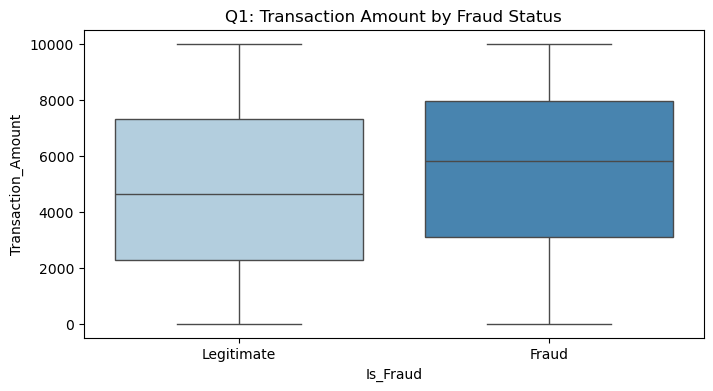

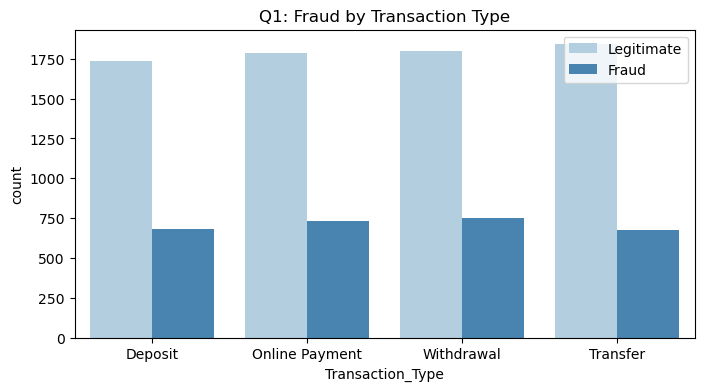

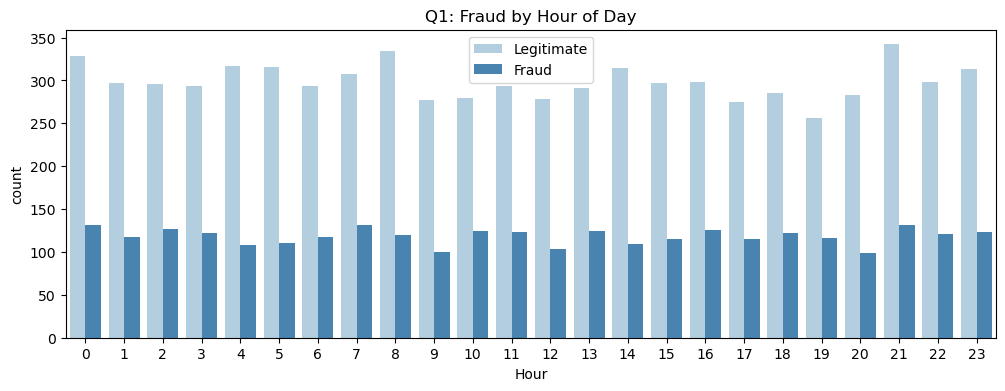

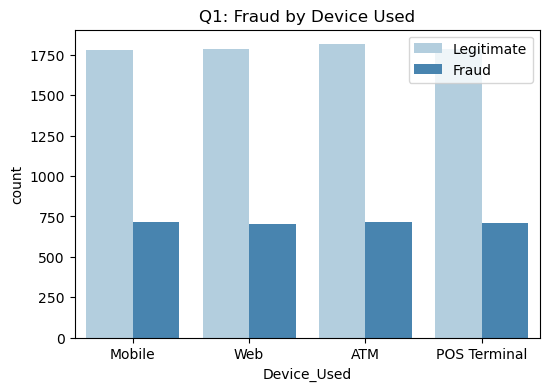

In [16]:
# Transaction Amount by Fraud Status
plt.figure(figsize=(8,4))
sns.boxplot(x='Is_Fraud', data=bf, y='Transaction_Amount', palette='Blues')
plt.title('Q1: Transaction Amount by Fraud Status')
plt.xticks([0,1], ['Legitimate', 'Fraud'])
plt.show()

# Fraud by Transaction Type
plt.figure(figsize=(8,4))
sns.countplot(x='Transaction_Type', hue='Is_Fraud', data=bf, palette='Blues')
plt.title('Q1: Fraud by Transaction Type')
plt.legend(['Legitimate', 'Fraud'])
plt.show()

# Fraud by Hour of Day
plt.figure(figsize=(12,4))
sns.countplot(x='Hour', hue='Is_Fraud', data=bf, palette='Blues')
plt.title('Q1: Fraud by Hour of Day')
plt.legend(['Legitimate', 'Fraud'])
plt.show()

# Fraud by Device Used
plt.figure(figsize=(6,4))
sns.countplot(x='Device_Used', hue='Is_Fraud', data=bf, palette='Blues')
plt.title('Q1: Fraud by Device Used')
plt.legend(['Legitimate', 'Fraud'])
plt.show()

# NOTE: 
- Fraudulent transactions tend to involve higher amounts than legitimate ones, 
  making transaction amount a key fraud indicator.
- Fraud is present across all transaction types, with Deposits and Withdrawals 
  showing a slightly higher proportion of fraudulent activity.
- Fraud occurs consistently across all hours of the day, suggesting that time 
  alone is not a strong predictor of fraud.
- Fraud is spread evenly across all devices — Mobile, Web, ATM, and POS Terminal 
  — meaning device type is not a strong standalone fraud signal.